# Black-Scholes Pricing Demonstration

This notebook demonstrates the implementation of the Black–Scholes model for European options, including:

- Call and put pricing  
- Greeks (Delta, Gamma, Vega, Theta, Rho)  
- Sensitivity analysis  
- Basic visualizations  

## Black-Scholes Model

For a European option with:

- $S$: underlying price  
- $K$: strike  
- $r$: risk‑free rate  
- $\sigma$: volatility  
- $t$: time to maturity  
<br>

$N(x)$ denotes the standard normal cumulative distribution function

$N(x) = \frac{1}{\sqrt{2\pi}} \int_{-\infty}^{x} e^{-t^2/2} dt$ <br><br>

   
   
$N'(x)$ denotes the standard normal probability density function

$N'(x) = \frac{1}{\sqrt{2\pi}} e^{-x^2/2}$ <br><br>   

We define:

$$d_1 = \frac{\ln(S/K) + (r + \frac{1}{2}\sigma^2)t}{\sigma\sqrt{t}}$$

$$d_2 = d_1 - \sigma\sqrt{t}$$


Call price:

$$C = S N(d_1) - K e^{-rt} N(d_2)$$


Put price:

$$P = K e^{-rt} N(-d_2) - S N(-d_1)$$

### Instantiate the Model

We start by defining a standard set of parameters for the underlying asset and option and instantiate the model

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from options_pricing.models.black_scholes import BlackScholes

In [2]:
S = 100      # Spot price
K = 100      # Strike
r = 0.05     # Risk-free rate
t = 1.0      # Time to maturity (years)
sigma = 0.20 # Volatility

bs_model = BlackScholes(S, K, r, t, sigma)
bs_model

### Pricing Examples

In [3]:
call_price = bs_model.call_price()
put_price = bs_model.put_price()

print("Call price: " + str(call_price))
print("Put price: " + str(put_price))

Call price: 10.450583572185565
Put price: 5.573526022256971


## Greeks

We compute the Greeks to understand the sensitivity of the option price to:

- Spot price (Delta, Gamma)
- Volatility (Vega)
- Time (Theta)
- Interest rate (Rho)


|      |                                      | Call |  Put  |
| :---:|:---:                                 |:---: | :---: |
| Delta| $\frac{\partial V}{\partial S}$      |$N(d_1)$                          | $N(d_1) - 1$                      |
| Gamma| $\frac{\partial^2 V}{\partial S^2}$  |$\frac{N'(d_1)}{S\sigma\sqrt{t}}$ | $\frac{N'(d_1)}{S\sigma\sqrt{t}}$ |
| Vega | $\frac{\partial V}{\partial \sigma}$ |$SN'(d_1)\sqrt{t}$ | $SN'(d_1)\sqrt{t}$ |
| Theta| $\frac{\partial V}{\partial t}$      |$-\frac{SN'(d_1)\sigma}{2\sqrt{t}} - rKe^{-rt}N(d_2)$ | $-\frac{SN'(d_1)\sigma}{2\sqrt{t}} + rKe^{-rt}N(-d_2)$ |
| Rho  | $\frac{\partial V}{\partial r}$      |$Kte^{-rt}N(d_2)$ | $-Kte^{-rt}N(-d_2)$ |


In [4]:
print("Call delta: " + str(bs_model.delta("call")))
print("Put delta: " + str(bs_model.delta("put")))

print("\nGamma: " + str(bs_model.gamma()))

print("\nVega: " + str(bs_model.vega()))

print("\nCall theta: " + str(bs_model.theta(option_type="call")))
print("Put theta: " + str(bs_model.theta(option_type="put")))

print("\nCall rho: " + str(bs_model.rho("call")))
print("Put rho: " + str(bs_model.rho("put")))

Call delta: 0.6368306511756191
Put delta: -0.3631693488243809

Gamma: 0.018762017345846895

Vega: 37.52403469169379

Call theta: -6.414027546438197
Put theta: -1.657880423934626

Call rho: 53.232481545376345
Put rho: -41.89046090469506


### Call Price vs Spot Price

We examine how the call price changes as the underlying asset price varies.


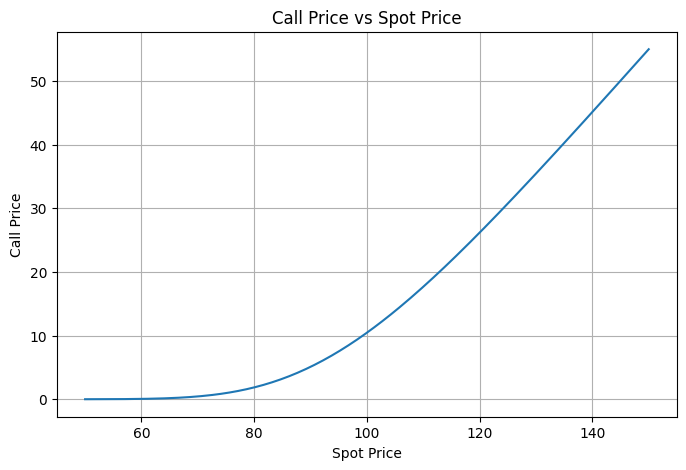

In [5]:
spots = np.linspace(50, 150, 200)
call_prices = [BlackScholes(S=x, K=K, r=r, t=t, sigma=sigma).call_price() for x in spots]

plt.figure(figsize=(8,5))
plt.plot(spots, call_prices)
plt.title("Call Price vs Spot Price")
plt.xlabel("Spot Price")
plt.ylabel("Call Price")
plt.grid(True)
plt.show()

### Delta vs Spot Price

Delta shows how sensitive the option price is to changes in the underlying asset price.


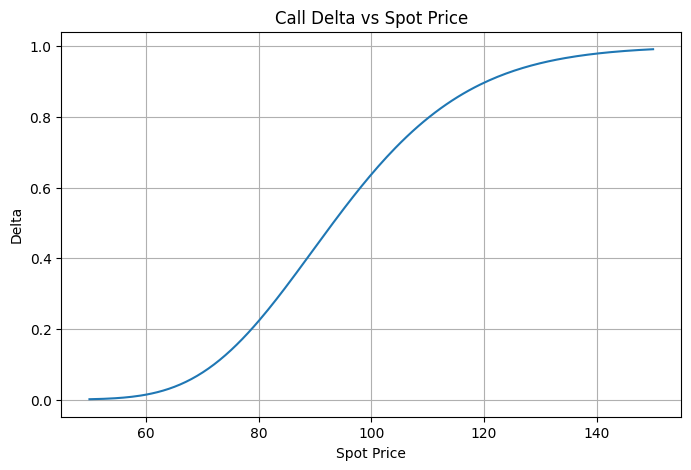

In [6]:
deltas = [BlackScholes(S=x, K=K, r=r, t=t, sigma=sigma).delta("call") for x in spots]

plt.figure(figsize=(8,5))
plt.plot(spots, deltas)
plt.title("Call Delta vs Spot Price")
plt.xlabel("Spot Price")
plt.ylabel("Delta")
plt.grid(True)
plt.show()

### Gamma vs Spot Price

Gamma represents the sensitivity of an options's delta to underlying price movements.

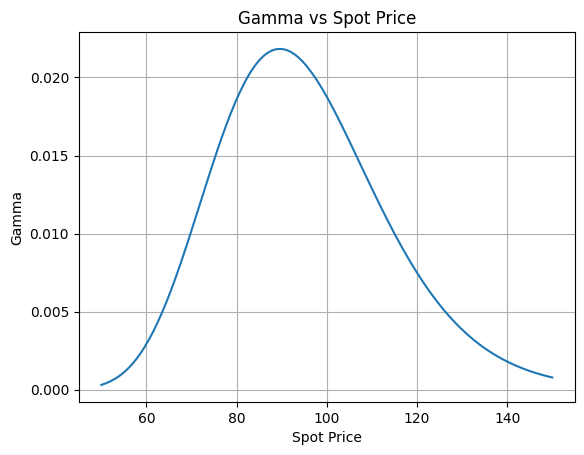

In [7]:
S_values = np.linspace(50, 150, 200)
gammas = [
    BlackScholes(S=s, K=100, r=0.05, sigma=0.20, t=1.0).gamma()
    for s in S_values
]

plt.plot(S_values, gammas)
plt.title("Gamma vs Spot Price")
plt.xlabel("Spot Price")
plt.ylabel("Gamma")
plt.grid(True)
plt.show()

### Vega and Volatility Sensitivity

We examine how the option price changes with volatility.


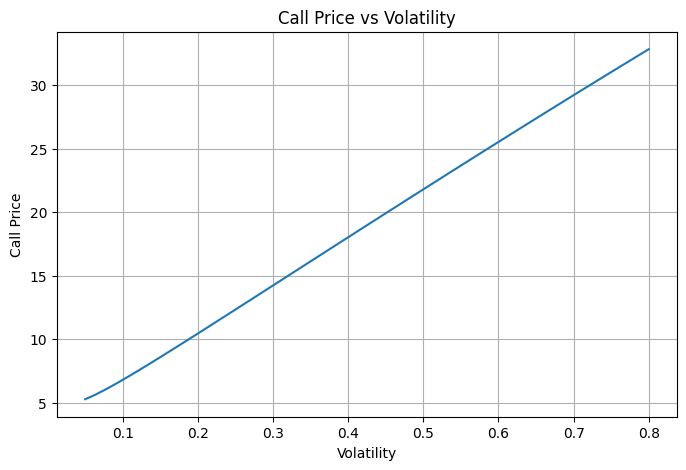

In [8]:
vols = np.linspace(0.05, 0.80, 100)
call_vol_sensitivity = [
    BlackScholes(S=S, K=K, r=r, t=t, sigma=v).call_price() for v in vols
]

plt.figure(figsize=(8,5))
plt.plot(vols, call_vol_sensitivity)
plt.title("Call Price vs Volatility")
plt.xlabel("Volatility")
plt.ylabel("Call Price")
plt.grid(True)
plt.show()